In [1]:
# Check if autoreload is loaded and load/reload accordingly
try:
    %reload_ext autoreload
except Exception:
    %load_ext autoreload
%autoreload 2

# from tqdm.notebook import tqdm

# Basic useful imports
from pathlib import Path
import h5py

# Data manipulation
import numpy as np
from scipy.integrate import quad
import scipy.stats as stats
from scipy.optimize import root_scalar

# Visualization
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Clustering stuff
from itertools import cycle
# plt.cm.tab20.colors

# From alens_analysis.py
import alens_analysis.chromatin.chrom_analysis as ca
import alens_analysis.chromatin.chrom_graph_funcs as cgf
from alens_analysis import cluster_analysis as cla

# Locations
ws_path = Path("/home/alamson/DATA/Chromatin/")
mnt_path = Path.home() / "projects/DATA/Chromatin/"
ceph_path = Path.home() / "ceph/DATA/Chromatin/"

image_path = Path("/mnt/home/alamson/papers/dyn_cond_paper/images/")


In [2]:
# Consistent settings
ss_ind = 1
end_ind = None
start_bead = 0
end_bead = None
part_min = 40

# Diffusion time
visc = 1.0 # pN*s/um^2
b_diam = 0.01 # um
kbT = .00411 # pN*um
L_tot = 1600 # beads
L_tot_um = L_tot * b_diam
bead_diff = kbT / (3 * np.pi * visc * b_diam) # um^2/s
diff_time =  b_diam**2 / (6*bead_diff) # s
print(f"Diffusion time: {diff_time:.5f} s")

Diffusion time: 0.00038 s


### Style settings

In [3]:
graph_sty = {
    "axes.titlesize": 20,
    "axes.labelsize": 24,
    "lines.linewidth": 2,
    "lines.markersize": 2,
    "xtick.labelsize": 24,
    "ytick.labelsize": 24,
    "font.size": 20,
    "text.usetex": False,
    "mathtext.fontset": "cm",
}
plt.style.use(graph_sty)

colors = cycle(mcolors.XKCD_COLORS.keys())
plt.rcParams["image.cmap"] = "YlOrRd"

def reset_scale(fig, new_width):
    w_old, h_old = fig.get_size_inches()

    fig.set_size_inches(new_width, new_width * h_old / w_old)
    scale = new_width / w_old
    mpl.rcParams["axes.titlesize"] *= scale
    mpl.rcParams["axes.labelsize"] *= scale
    mpl.rcParams["lines.linewidth"] *= scale
    mpl.rcParams["lines.markersize"] *= scale
    mpl.rcParams["xtick.labelsize"] *= scale
    mpl.rcParams["ytick.labelsize"] *= scale
    mpl.rcParams["font.size"] *= scale

In [4]:
def plot_confidence_int(
    ax,
    time_arr,
    mean,
    std_dev,
    num_runs=12,
    color="b",
    ci=0.95,
    label="Mean",
    alpha=1.0,
):
    degrees_freedom = num_runs
    confidence_interval = (
        stats.t.ppf((1 + ci) / 2.0, degrees_freedom) * std_dev / np.sqrt(num_runs)
    )

    _ = ax.plot(time_arr, mean, label=label, color=color, alpha=alpha)
    _ = ax.fill_between(
        time_arr,
        mean - confidence_interval,
        mean + confidence_interval,
        color=color,
        alpha=0.1,
    )

In [5]:
# Functions
def free_energy_droplet(Ld, mu, alpha, gamma):
    return -mu * alpha * Ld + gamma * 4.0 * np.pi * np.power(
        3.0 * alpha * Ld / (4 * np.pi), 2.0 / 3.0
    )


def free_energy_polymer(Ld, Ltot, Lsep, kappa):
    eps = Ltot - Ld
    return (
        0.25
        * kappa
        * ((eps / (1.0 - (Lsep / eps))) - Lsep + 2.0 * ((Lsep * Lsep) / eps) - eps)
    )


def tot_free_energy(Ld, Ltot, Lsep, mu, alpha, gamma, kappa):
    return free_energy_droplet(Ld, mu, alpha, gamma) + free_energy_polymer(
        Ld, Ltot, Lsep, kappa
    )


def free_energy_deriv(Ld, Ltot, Lsep, mu, alpha, gamma, kappa):
    return -mu * alpha + (1.0 / 12.0) * (
        8.0 * np.power(6.0 * alpha, 2.0 / 3.0) * gamma * np.power(np.pi / Ld, 1.0 / 3.0)
        + 3.0
        * kappa
        * (Lsep**2)
        * (2.0 / np.power(Ld - Ltot, 2.0) + 1.0 / np.power(Lsep + Ld - Ltot, 2.0))
    )


def length_prob_unnorm(Ld, Ltot, Lsep, mu, alpha, gamma, kappa, beta=1.0 / 0.0041):
    return np.exp(-beta * tot_free_energy(Ld, Ltot, Lsep, mu, alpha, gamma, kappa))
    # return tot_free_energy(Ld, Ltot, Lsep, mu, alpha, gamma, kappa)


def partition_function(Ltot, Lsep, mu, alpha, gamma, kappa, beta=1.0 / 0.0041):
    return quad(
        lambda Ld: np.exp(
            -beta * tot_free_energy(Ld, Ltot, Lsep, mu, alpha, gamma, kappa)
        ),
        0,
        Ltot - (Lsep * 1.001),
    )

# Supplemental figure theory experiment compare 

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


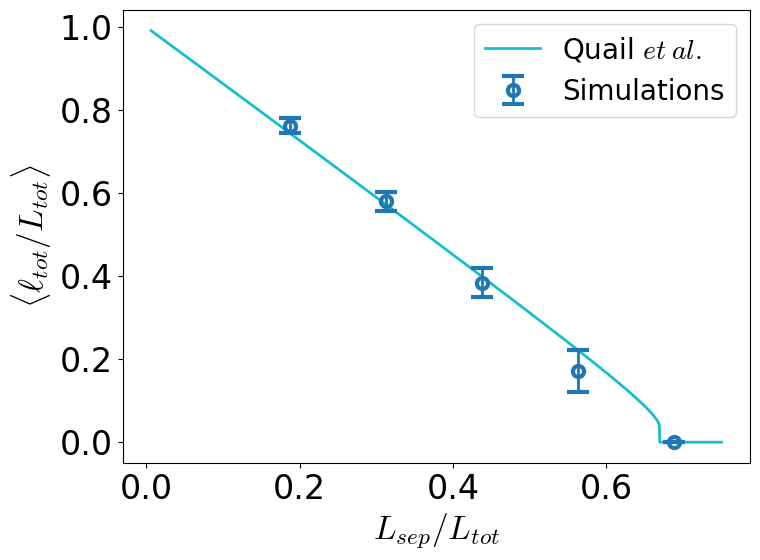

In [6]:
labels_to_graph_dict = {
    r"$K_e = 3~\mu {\rm M}^{-1}, L_{sep} = 5~\mu {\rm m}$": "Pin5.0um_Ke3/",
    # r"$K_e = 10~\mu {\rm M}^{-1}, L_{sep} = 5~\mu {\rm m}$": "Pin5.0um_Ke10/",
    r"$K_e = 30~\mu {\rm M}^{-1}, L_{sep} = 5~\mu {\rm m}$": "Pin5.0um_Ke30/",
    r"$K_e = 100~\mu {\rm M}^{-1}, L_{sep} = 5~\mu {\rm m}$": "Pin5.0um_Ke100",
    r"$K_e = 30~\mu {\rm M}^{-1}, L_{sep} = 3~\mu {\rm m}$": "Pin3.0um_Ke30",
    # r"$K_e = 30~\mu {\rm M}^{-1}, L_{sep} = 7~\mu {\rm m}$": "Pin7.0um_Ke30",
    r"$K_e = 30~\mu {\rm M}^{-1}, L_{sep} = 9~\mu {\rm m}$": "Pin9.0um_Ke30",
}
colors = ["C1", "C0", "C2", "C3", "C4"]

# Panel C: Theory comparison figure
fig, ax = plt.subplots(figsize=(8, 6))

# Read Ke=30 data for comparison with theory
with h5py.File("Figure2/fig2_pin_ke_data_dict.h5", "r") as h5d:
    time_arr = h5d["time"][...]
    pin_dist_arr = []
    beads_num_arr = []
    beads_std_arr = []
    
    for label in h5d.keys():
        if label != "time":
            h5_data = h5d[label]
            Ke, pin_dist = h5_data.attrs["Ke"], h5_data.attrs["pin_dist"]
            if Ke == 30:
                pin_dist_arr.append(pin_dist)
                tot_cond = h5_data['first_mom'][...] * h5_data['zeroth_mom'][...]
                beads_num_arr.append(tot_cond[-time_arr.size // 5:].mean())
                beads_std_arr.append(tot_cond[-time_arr.size // 5:].std())

# Theory parameters
mu = 4.1  # Free energy per volume pN/um^2
alpha = 0.05  # Condensate packing factor um^2
gamma = 0.15  # Surface tension pN/um
kappa = 0.0822  # Filament flexibility pN
Ltot = 16.0  # Total length of the polymer um

# Calculate theoretical predictions
lsep_arr = np.linspace(0.1, 12, 1000)
ld_max_prob = np.zeros(lsep_arr.size)

for i, lsep in enumerate(lsep_arr):
    bound = 0.1
    while free_energy_deriv(bound, Ltot, lsep, mu, alpha, gamma, kappa) > 0:
        bound += 0.5
    if bound > Ltot - (lsep * 1.0000001):
        ld_max_prob[i] = 0.0
        continue
    result = root_scalar(
        free_energy_deriv,
        method="brentq",
        bracket=[bound, Ltot - (lsep * 1.0000001)],
        args=(Ltot, lsep, mu, alpha, gamma, kappa),
    )
    ld_max_prob[i] = result.root

# Plot theory and simulations
_ = ax.plot(
    lsep_arr / Ltot,
    ld_max_prob / Ltot,
    label=r"Quail $\mathit{et\:al.}$",
    color="C9",
)
_ = ax.errorbar(
    np.array(pin_dist_arr) / 16.0,
    np.array(beads_num_arr) / 1600.0,
    yerr=np.array(beads_std_arr) / 1600.0,
    fmt="o",
    markeredgewidth=3,
    markeredgecolor="C0",
    markersize=8,
    markerfacecolor="none",
    capsize=8,
    label="Simulations",
)
_ = ax.set_xlabel(r"$L_{sep}/L_{tot}$")
_ = ax.set_ylabel(r"$\langle \ell_{tot}/L_{tot} \rangle$")
_ = ax.legend()

fig.tight_layout()

fig.savefig("SFig_theory_exp_comp/sfig_theory_exp_comparison.eps", dpi=600, bbox_inches="tight")
fig.savefig("SFig_theory_exp_comp/sfig_theory_exp_comparison.pdf", dpi=600, bbox_inches="tight")
fig.savefig(image_path / "sfig_theory_exp_comparison.eps", dpi=600, bbox_inches="tight")
fig.savefig(image_path / "sfig_theory_exp_comparison.pdf", dpi=600, bbox_inches="tight")
